<h2 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
0. Import Libraries

</font>
</h2>

In [19]:
import keras
print(keras.__version__)

3.10.0


In [20]:
import pandas as pd
import numpy as np

<h2 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
1. Data Loading
</font>
</h2>

In [ ]:
from keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    directory='./train/',
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset='training'
)
class_names = train_dataset.class_names
val_dataset = image_dataset_from_directory(
    directory='./train/',
    labels='inferred',
    label_mode='categorical',
    color_mode='rgb',
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset='validation'
)

Found 8829 files belonging to 11 classes.
Using 7947 files for training.
Found 8829 files belonging to 11 classes.
Using 882 files for validation.


In [22]:
class_names

['0', '1', '10', '2', '3', '4', '5', '6', '7', '8', '9']

<h3 align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
2. Preprocessing
</font>
</h3>

In [ ]:
from keras.applications.resnet50 import preprocess_input

train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
val_dataset = val_dataset.map(lambda x, y: (preprocess_input(x), y))

<h2  align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
3. Model Development
</font>
</h2>

In [ ]:
model = keras.applications.ResNet50(input_shape= (224, 224, 3),
                                      classes= 11,
                                      weights= None,
                                      include_top= False,
                                      pooling= 'avg'
                                      )
model.load_weights(
    "resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"
)
model.trainable = False
x = keras.layers.Flatten()(model.output)
x = keras.layers.Dense(128,activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64,activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(11, activation='softmax')(x)
model = keras.models.Model(model.input, x)

In [37]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,401,443 (93.08 MB)

 Trainable params: 271,243 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 542,488 (2.07 MB)

In [26]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("model.keras", save_best_only=True, monitor="val_loss")

early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

initial_learning_rate = 0.001

def scheduler(epoch, lr):
    if epoch % 10 == 0:
        return lr * 0.9
    else:
        return lr

lr_scheduler = keras.callbacks.LearningRateScheduler(scheduler)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=initial_learning_rate),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

<h2  align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
4. Training
</font>
</h2>

In [27]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=40, callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 387s 2s/step - accuracy: 0.5224 - loss: 1.4081 - val_accuracy: 0.8220 - val_loss: 0.5328
Epoch 2/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.7816 - loss: 0.6980 - val_accuracy: 0.8367 - val_loss: 0.4820
Epoch 3/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.8122 - loss: 0.5756 - val_accuracy: 0.8594 - val_loss: 0.4426
Epoch 4/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.8304 - loss: 0.5184 - val_accuracy: 0.8515 - val_loss: 0.4160
Epoch 5/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 537s 2s/step - accuracy: 0.8529 - loss: 0.4657 - val_accuracy: 0.8492 - val_loss: 0.4336
Epoch 6/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.8584 - loss: 0.4268 - val_accuracy: 0.8537 - val_loss: 0.4237
Epoch 7/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.8695 - loss: 0.4088 - val_accuracy: 0.8605 - val_loss: 0.4171
Epoch 8/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.8762 - loss: 0.3642 - val_accu

<h2  align=left style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
5. Evaluation
</font>
</h2>



In [28]:
best_model = keras.models.load_model("model.keras")

In [ ]:
best_model.evaluate(val_dataset)

28/28 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8721 - loss: 0.3848


[0.39371395111083984, 0.8673469424247742]

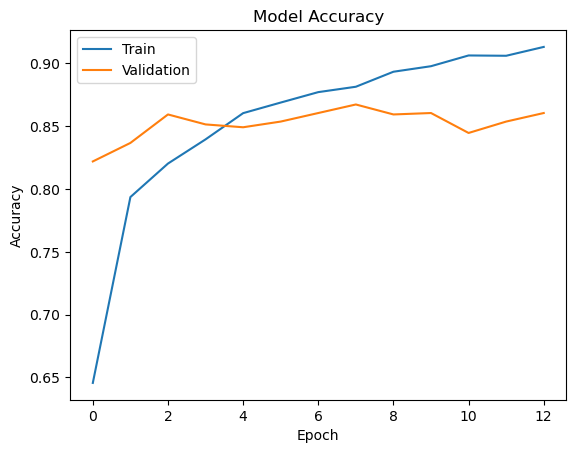

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()